# Food Order Prediction using 

This notebook predicts the most likely **cuisine type** for a food order using a clean synthetic Vijayawada dataset. The workflow uses the same fixed 80/20 stratified split and preprocessing pipeline across all models.

**Target:** `Cuisine_Type`

**Input features:** Gender, Age_Group, Marital_Status, Income_Level, Time_of_Day, Day, Location

## 1. Load and validate the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns

DATA_FILE = "vijayawada_food_orders_dataset.csv"
df = pd.read_csv(DATA_FILE)
X = df.drop(columns="Cuisine_Type")
y = df["Cuisine_Type"]
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)
categorical_features = X.columns.tolist()
preprocessor = ColumnTransformer([("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)])
print("Dataset shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Training rows:", len(X_train), "| Testing rows:", len(X_test))


Dataset shape: (10000, 8)
Missing values: 0
Duplicate rows: 0
Training rows: 8000 | Testing rows: 2000


In [2]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=12, min_samples_split=2, random_state=42)

In [3]:
pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", model)])
pipeline.fit(X_train, y_train)
print("Model trained successfully.")
grid_search = pipeline


Model trained successfully.


## 3. Evaluate on the held-out test set

In [4]:
y_pred = grid_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")
print(f"F1-score : {f1:.2%}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

Accuracy : 59.10%
Precision: 59.40%
Recall   : 59.10%
F1-score : 58.67%

Classification Report:

              precision    recall  f1-score   support

      Bakery       0.55      0.72      0.62       154
     Biryani       0.63      0.56      0.60       487
     Chinese       0.56      0.54      0.55       156
 Continental       0.65      0.57      0.61       159
   Fast Food       0.53      0.56      0.54       254
North Indian       0.61      0.60      0.60       158
South Indian       0.59      0.75      0.66       378
 Street Food       0.59      0.40      0.48       254

    accuracy                           0.59      2000
   macro avg       0.59      0.59      0.58      2000
weighted avg       0.59      0.59      0.59      2000



## 4. Confusion matrix

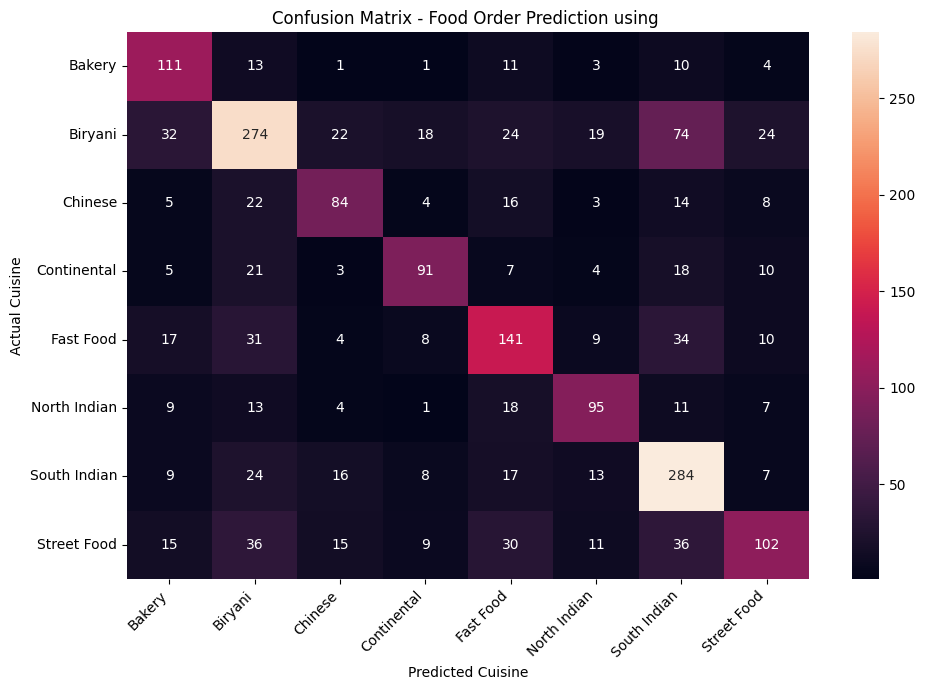

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Food Order Prediction using ")
plt.xlabel("Predicted Cuisine")
plt.ylabel("Actual Cuisine")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Example prediction

In [6]:
sample = pd.DataFrame([{"Gender":"Female", "Age_Group":"25-34", "Marital_Status":"Single", "Income_Level":"Upper-Middle", "Time_of_Day":"Dinner", "Day":"Saturday", "Location":"MG Road"}])
prediction = grid_search.predict(sample)[0]
print("Example input:")
display(sample)
print("Predicted cuisine:", label_encoder.inverse_transform([prediction])[0])

Example input:


,Gender,Age_Group,Marital_Status,Income_Level,Time_of_Day,Day,Location
0,Female,25-34,Single,Upper-Middle,Dinner,Saturday,MG Road


Predicted cuisine: Chinese


## Conclusion

Decision Tree can model non-linear interactions among the categorical order features. The tuned model is evaluated only on the held-out test set. Results must be taken from the executed test-set cell; no accuracy value is assumed in advance.